# Breast Cancer Classification — KNN with Cross-Validation

This notebook demonstrates:
- Loading a built-in sklearn dataset
- Comparing Naive Bayes and kNN
- Why feature scaling matters for kNN
- Using KFold cross-validation to find the best k
- Using `make_pipeline` to combine scaling + model

---

### Imports and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
X = bc.data
y = bc.target

print(f"Features: {X.shape}  (samples, features)")
print(f"Target: {y.shape}, classes: {np.unique(y)}")
print(f"Feature names: {list(bc.feature_names[:5])}... ({len(bc.feature_names)} total)")

Features: (569, 30)  (samples, features)
Target: (569,), classes: [0 1]
Feature names: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]... (30 total)


### Train/test split

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1138)

### Baseline: Naive Bayes (doesn't need scaling)

In [4]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

print(f"Naive Bayes accuracy: {model.score(X_test, y_test):.4f}")
print(classification_report(y_test, model.predict(X_test)))

Naive Bayes accuracy: 0.9650
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        52
           1       0.96      0.99      0.97        91

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



### kNN without scaling

In [5]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train, y_train)
print(f"kNN (k=9, unscaled) accuracy: {model.score(X_test, y_test):.4f}")

kNN (k=9, unscaled) accuracy: 0.9301


### Why scaling matters for kNN

kNN uses distance between points. Features with larger ranges
dominate the distance calculation. Look at the different scales:

In [6]:
bc_df = pd.DataFrame(bc.data, columns=bc.feature_names)
print(bc_df[['mean radius', 'texture error', 'worst concavity']].describe())
# mean radius: ~6-28, texture error: ~0.3-4.8, worst concavity: ~0-1.2
# These are very different scales — kNN will be dominated by mean radius

       mean radius  texture error  worst concavity
count   569.000000     569.000000       569.000000
mean     14.127292       1.216853         0.272188
std       3.524049       0.551648         0.208624
min       6.981000       0.360200         0.000000
25%      11.700000       0.833900         0.114500
50%      13.370000       1.108000         0.226700
75%      15.780000       1.474000         0.382900
max      28.110000       4.885000         1.252000


### kNN with scaling via Pipeline

`make_pipeline` chains steps together. When you call `.fit()`, it runs
each step in order. This ensures scaling is always applied consistently.

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=9)
)
model.fit(X_train, y_train)
print(f"kNN (k=9, scaled) accuracy: {model.score(X_test, y_test):.4f}")
# Should be noticeably better than unscaled

kNN (k=9, scaled) accuracy: 0.9720


---
### Cross-validation with KFold — without scaling

KFold splits the training data into k folds. Each fold takes a turn
as the validation set. We get k scores and average them.

We loop over different values of k (neighbours) to find the best one.

In [8]:
from sklearn.model_selection import KFold

n_folds = 5
ks = range(1, 21)  # k=1 to k=20
train_scores = np.zeros((len(ks), n_folds))
valid_scores = np.zeros((len(ks), n_folds))

kf = KFold(n_splits=n_folds, shuffle=False)
# shuffle=False here because train_test_split already shuffled.
# If you haven't shuffled earlier, set shuffle=True.

for idx, k in enumerate(ks):
    fold = 0
    for train_index, val_index in kf.split(X_train):
        X_c, X_val = X_train[train_index], X_train[val_index]
        y_c, y_val = y_train[train_index], y_train[val_index]

        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_c, y_c)

        train_scores[idx, fold] = knn.score(X_c, y_c)
        valid_scores[idx, fold] = knn.score(X_val, y_val)
        fold += 1

mean_train = train_scores.mean(axis=1)
mean_valid = valid_scores.mean(axis=1)

bestk_unscaled = ks[np.argmax(mean_valid)]
print(f"Best k (unscaled): {bestk_unscaled}, CV accuracy: {mean_valid.max():.4f}")

Best k (unscaled): 6, CV accuracy: 0.9437


### Cross-validation with KFold — with StandardScaler in pipeline

In [9]:
train_scores_sc = np.zeros((len(ks), n_folds))
valid_scores_sc = np.zeros((len(ks), n_folds))

kf = KFold(n_splits=n_folds, shuffle=False)

for idx, k in enumerate(ks):
    fold = 0
    for train_index, val_index in kf.split(X_train):
        X_c, X_val = X_train[train_index], X_train[val_index]
        y_c, y_val = y_train[train_index], y_train[val_index]

        # Pipeline: scale inside each fold (no data leakage)
        est = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k)
        )
        est.fit(X_c, y_c)

        train_scores_sc[idx, fold] = est.score(X_c, y_c)
        valid_scores_sc[idx, fold] = est.score(X_val, y_val)
        fold += 1

mean_train_sc = train_scores_sc.mean(axis=1)
mean_valid_sc = valid_scores_sc.mean(axis=1)

bestk_scaled = ks[np.argmax(mean_valid_sc)]
print(f"Best k (scaled): {bestk_scaled}, CV accuracy: {mean_valid_sc.max():.4f}")

Best k (scaled): 3, CV accuracy: 0.9695


### Plot: accuracy vs k

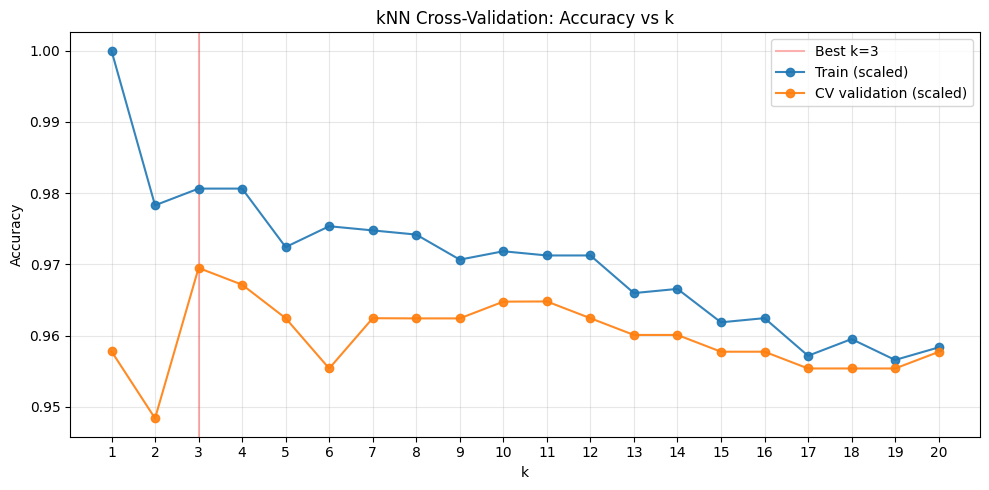

In [10]:
plt.figure(figsize=(10, 5))
plt.axvline(bestk_scaled, color='r', alpha=0.3, label=f'Best k={bestk_scaled}')
plt.plot(ks, mean_train_sc, marker='o', label='Train (scaled)', alpha=0.9)
plt.plot(ks, mean_valid_sc, marker='o', label='CV validation (scaled)', alpha=0.9)
plt.xticks(range(1, 21))
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('kNN Cross-Validation: Accuracy vs k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Final evaluation on the held-out test set

In [11]:
# Use the best k found by cross-validation
final = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=bestk_scaled)
)
final.fit(X_train, y_train)
print(f"Test accuracy (k={bestk_scaled}, scaled): {final.score(X_test, y_test):.4f}")
print(classification_report(y_test, final.predict(X_test)))

Test accuracy (k=3, scaled): 0.9860
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        52
           1       0.98      1.00      0.99        91

    accuracy                           0.99       143
   macro avg       0.99      0.98      0.98       143
weighted avg       0.99      0.99      0.99       143

